In [5]:
# Import Libraries
import yfinance as yf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input
import xgboost as xgb

In [3]:
pip install xgboost


   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB 262.6 kB/s eta 0:07:56
   ---------------------------------------- 0.0/124.9 MB 245.8 kB/s eta 0:08:29
   ---------------------------------------- 0.1/124.9 MB 393.8 kB/s eta 0:05:17
   ---------------------------------------- 0.1/124.9 MB 522.9 kB/s eta 0:03:59
   ---------------------------------------- 0.2/124.9 MB 573.4 kB/s eta 0:03:38
   ---------------------------------------- 0.2/124.9 MB 583.1 kB/s eta 0:03:34
   ---------------------------------------- 0.2/124.9 MB 583.1 kB/s eta 0:03:34
   ---------------------------------------- 0.2/124.9 MB 600.7 kB/s eta 0:03:28
   ---------------------------------------- 0.2/124.9 MB 600.7 kB/s eta 0:03:28
   ---------------------------------------- 0.3/124.9 MB 612.3 kB/s

In [7]:

# Load NSEBANK Stock Data
end = datetime.now()
start = datetime(end.year-10, end.month, end.day)
stock = "^NSEBANK"
stock_data = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [27]:
# Extract Close Prices
closing_price = stock_data[['Close']]

<Figure size 1500x500 with 0 Axes>

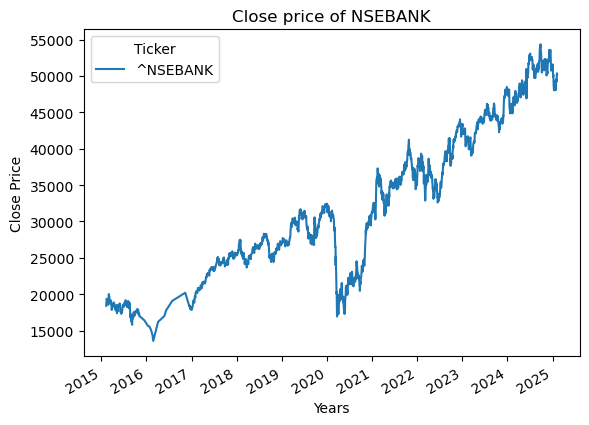

In [31]:
closing_price_.loc[:, 'MA_365'] = closing_price_['Close'].rolling(window=365).mean()
closing_price_.loc[:, 'MA_100'] = closing_price_['Close'].rolling(window=100).mean()


In [33]:
closing_price_ = closing_price_.copy()
closing_price_['MA_365'] = closing_price_['Close'].rolling(window=365).mean()
closing_price_['MA_100'] = closing_price_['Close'].rolling(window=100).mean()


In [35]:
# Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(closing_price[['Close']].values)

In [37]:
# Prepare LSTM Training Data
x_data, y_data = [], []
base_days = 100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])

x_data, y_data = np.array(x_data), np.array(y_data)

In [39]:
# Split Train-Test
len_train = int(len(x_data) * 0.9)
x_train, y_train = x_data[:len_train], y_data[:len_train]
x_test, y_test = x_data[len_train:], y_data[len_train:]


In [41]:
# Build LSTM_xg Model
lstm_model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=False),
    Dense(25),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(x_train, y_train, batch_size=5, epochs=10)

Epoch 1/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - loss: 0.0050
Epoch 2/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 6.1618e-04
Epoch 3/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 5.4448e-04
Epoch 4/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 3.9106e-04
Epoch 5/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 3.2114e-04
Epoch 6/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - loss: 2.8710e-04
Epoch 7/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 2.1597e-04
Epoch 8/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - loss: 2.8654e-04
Epoch 9/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - loss: 2.0020e-04
Epoch 10/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 2.0353e-04


In [43]:
# Extract Features from LSTM
lstm_features = lstm_model.predict(x_data)
lstm_features = lstm_features.reshape(-1, 1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step


In [45]:
# Prepare Data for XGBoost
features = np.concatenate([lstm_features, scaled_data[base_days:]], axis=1)
xgb_train, xgb_test = features[:len_train], features[len_train:]

In [47]:
# Train XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(xgb_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [49]:
# Make Predictions (LSTM + XGBoost)
lstm_preds = lstm_model.predict(x_test)
xgb_preds = xgb_model.predict(xgb_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [51]:
# Blend Predictions (Weighted Average)
final_predictions = 0.6 * lstm_preds + 0.4 * xgb_preds.reshape(-1, 1)

In [53]:
# Inverse Transform Predictions
inv_predictions = scaler.inverse_transform(final_predictions)
inv_y_test = scaler.inverse_transform(y_test)

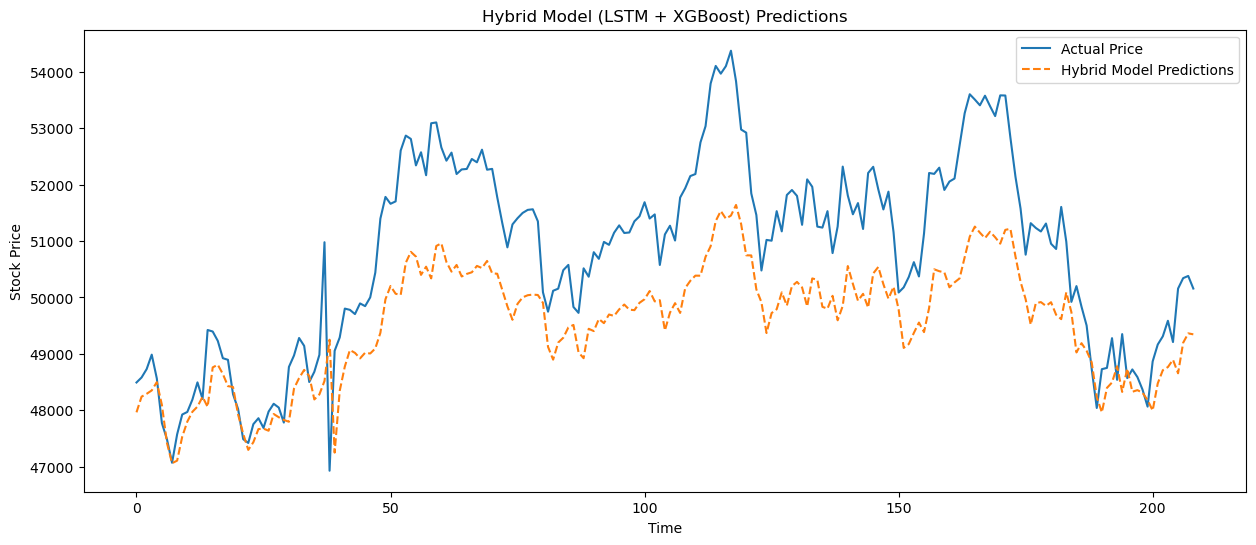

In [55]:
# Plot Results
plt.figure(figsize=(15,6))
plt.plot(inv_y_test, label='Actual Price')
plt.plot(inv_predictions, label='Hybrid Model Predictions', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Hybrid Model (LSTM + XGBoost) Predictions')
plt.legend()
plt.show()

In [57]:

# Save LSTM Model for Web Use
lstm_model.save("lstm_hybrid_model.keras")